
# TP1 - Classificação de Exoplanetas (Kepler / KOI)

**Disciplina:** Inteligência Artificial
**Trabalho Prático 1**

## Objetivo

Comparar seis métodos de classificação (Naive Bayes, Decision Tree, k-NN, SVM, Random
Forest e Gradient Tree Boosting) em um problema de classificação binária: distinguir
candidatos a exoplanetas (KOIs) da sonda Kepler que são **exoplanetas confirmados**
(`CONFIRMED`) de **falsos positivos** (`FALSE POSITIVE`).

Para cada método realizamos o experimento pedido no enunciado (variação de
hiperparâmetro, análise gráfica e discussão teórica), sempre usando validação cruzada
k-fold estratificada com $k=5$ e, quando há pré-processamento, aplicando-o **dentro**
do pipeline de validação para evitar vazamento de dados (*data leakage*).

## Estrutura do notebook

1. Configuração e imports
2. Carregamento e análise exploratória dos dados
3. Estratégia de avaliação (métricas e validação cruzada)
4. Pré-processamento: escolha e justificativa
5. Naive Bayes (baseline)
6. Decision Tree (variação da profundidade máxima)
7. k-NN (variação de k)
8. SVM (comparação de kernels)
9. Random Forest (variação do número de árvores)
10. Gradient Tree Boosting (variação do número de iterações)
11. Comparação final entre os métodos
12. Conclusão e escolha do modelo


## 1. Configuração e imports

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay, roc_curve, auc,
)

RANDOM_STATE = 42
N_SPLITS = 5

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

np.random.seed(RANDOM_STATE)



## 2. Carregamento e análise exploratória dos dados

O arquivo `koi_data.csv` contém uma linha por KOI (*Kepler Object of Interest*). A
primeira coluna (`kepoi_name`) é apenas um identificador e não deve ser usada como
feature. A segunda coluna (`koi_disposition`) é o rótulo (`CONFIRMED` ou
`FALSE POSITIVE`). As demais 41 colunas são features numéricas.


In [2]:

df = pd.read_csv("koi_data.csv")
print("Dimensões:", df.shape)
df.head()


Dimensões: (5202, 43)


,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   str    
 1   koi_disposition   5202 non-null   str    
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_snr     5202 non-null   float64
 17  koi_st

In [4]:

# Não há valores ausentes no conjunto de dados
print("Total de valores ausentes:", df.isna().sum().sum())


Total de valores ausentes: 0


In [5]:

# Distribuição das classes
class_counts = df["koi_disposition"].value_counts()
class_counts


koi_disposition
FALSE POSITIVE    3098
CONFIRMED         2104
Name: count, dtype: int64

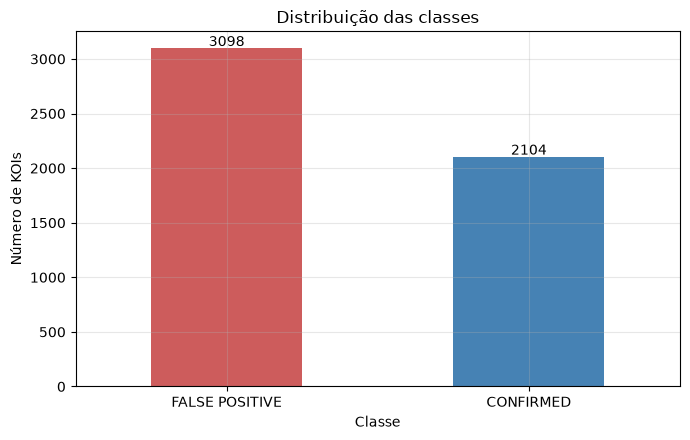

koi_disposition
FALSE POSITIVE    0.59554
CONFIRMED         0.40446
Name: count, dtype: float64


In [6]:

fig, ax = plt.subplots()
class_counts.plot(kind="bar", ax=ax, color=["indianred", "steelblue"])
ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de KOIs")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 20, str(v), ha="center")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

proporcao = class_counts / class_counts.sum()
print(proporcao)



As classes estão **moderadamente desbalanceadas**: cerca de 59.6% dos KOIs são falsos
positivos e 40.4% são exoplanetas confirmados. O desbalanceamento não é extremo, mas é
suficiente para que a **acurácia sozinha** possa ser enganosa (um classificador que
sempre prevê "FALSE POSITIVE" já acertaria ~60% dos casos sem aprender nada útil).
Por isso, ao longo do trabalho também acompanharemos **precisão, revocação, F1-score e
AUC-ROC**, que veremos com mais detalhe na Seção 3.


In [7]:

# Separação entre features (X) e rótulo (y). Convertendo o rótulo para binário:
# 1 = CONFIRMED (classe positiva: "é um exoplaneta"), 0 = FALSE POSITIVE
X = df.drop(columns=["kepoi_name", "koi_disposition"])
y = (df["koi_disposition"] == "CONFIRMED").astype(int)

feature_names = X.columns.tolist()
print(f"Número de features: {len(feature_names)}")
print(f"Número de amostras: {len(X)}")


Número de features: 41
Número de amostras: 5202


In [8]:

# Estatísticas descritivas das features. Note a grande diferença de escala entre
# colunas (ex.: koi_period vs koi_smet) e a forte assimetria (skew) de muitas delas.
desc = X.describe().T
desc["skew"] = X.skew()
desc[["mean", "std", "min", "max", "skew"]]


,mean,std,min,max,skew
koi_period,37.032237,88.417985,0.30694,1.071233e+03,4.015403
koi_impact,0.717106,2.628207,0.00000,1.008060e+02,31.526734
koi_duration,5.607025,6.962634,0.10460,1.385400e+02,6.587950
koi_depth,21340.318993,66989.808550,0.80000,8.642600e+05,4.596848
koi_ror,0.235205,2.586213,0.00129,9.987065e+01,32.575624
koi_srho,3.415370,25.131368,0.00004,9.187524e+02,27.811841
koi_prad,112.230798,3699.799318,0.08000,2.003460e+05,47.634642
koi_sma,0.158146,0.241792,0.00720,2.034500e+00,3.115686
koi_incl,81.181413,16.308839,2.29000,9.000000e+01,-2.759616
koi_teq,1143.721069,775.788868,92.00000,9.791000e+03,2.151209


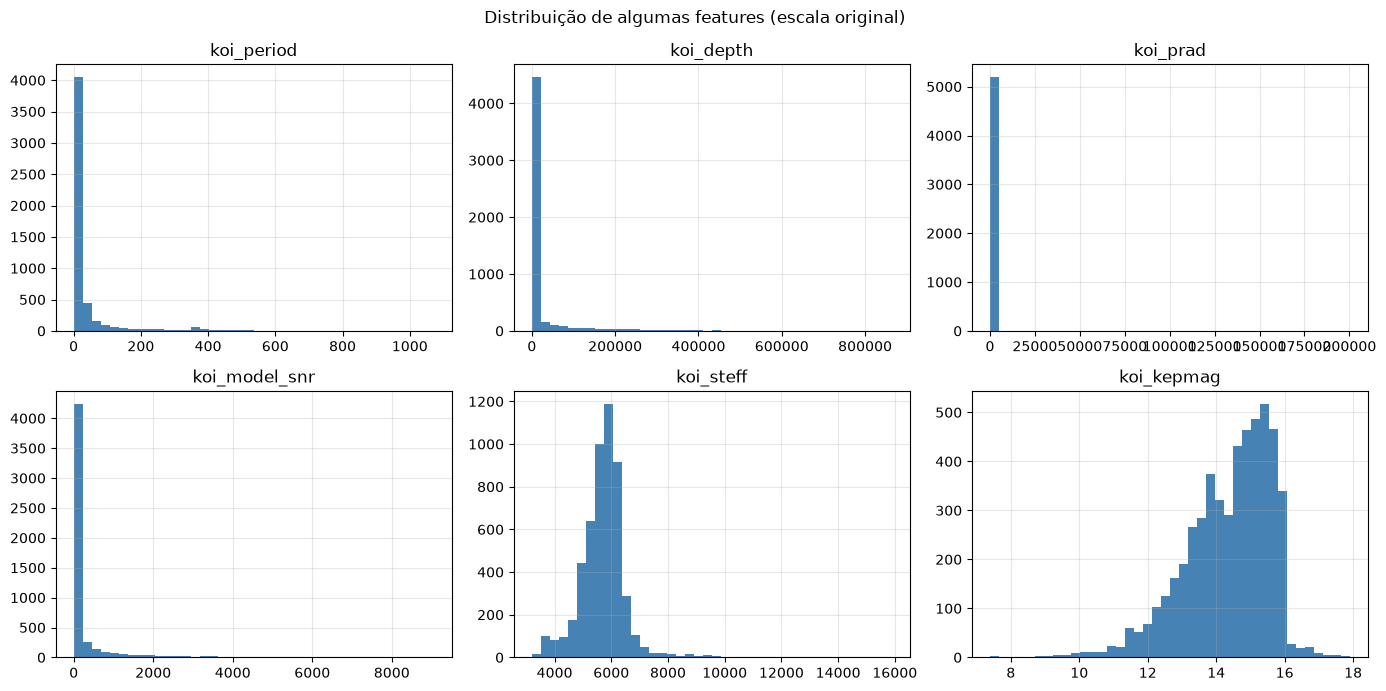

In [9]:

# Histogramas de algumas features para ilustrar a diferença de escala e a assimetria
cols_exemplo = ["koi_period", "koi_depth", "koi_prad", "koi_model_snr",
                 "koi_steff", "koi_kepmag"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), cols_exemplo):
    ax.hist(X[col], bins=40, color="steelblue")
    ax.set_title(col)
plt.suptitle("Distribuição de algumas features (escala original)")
plt.tight_layout()
plt.show()



Observamos que:

- As features têm **escalas muito diferentes** entre si (ex.: `koi_period` varia até
  ~1000, enquanto `koi_smet` varia entre -2.5 e 0.6).
- Muitas features são **fortemente assimétricas** (cauda longa à direita), o que é
  comum em grandezas físicas/astronômicas (períodos orbitais, profundidade de trânsito,
  raio do planeta, etc.).

Esses dois pontos motivam a etapa de pré-processamento discutida na Seção 4: métodos
baseados em distância ou em produtos internos (k-NN, SVM) e métodos probabilísticos que
assumem features aproximadamente gaussianas (Naive Bayes) são sensíveis a essas
características, enquanto métodos baseados em árvores (Decision Tree, Random Forest,
Gradient Boosting) são invariantes a transformações monotônicas das features.


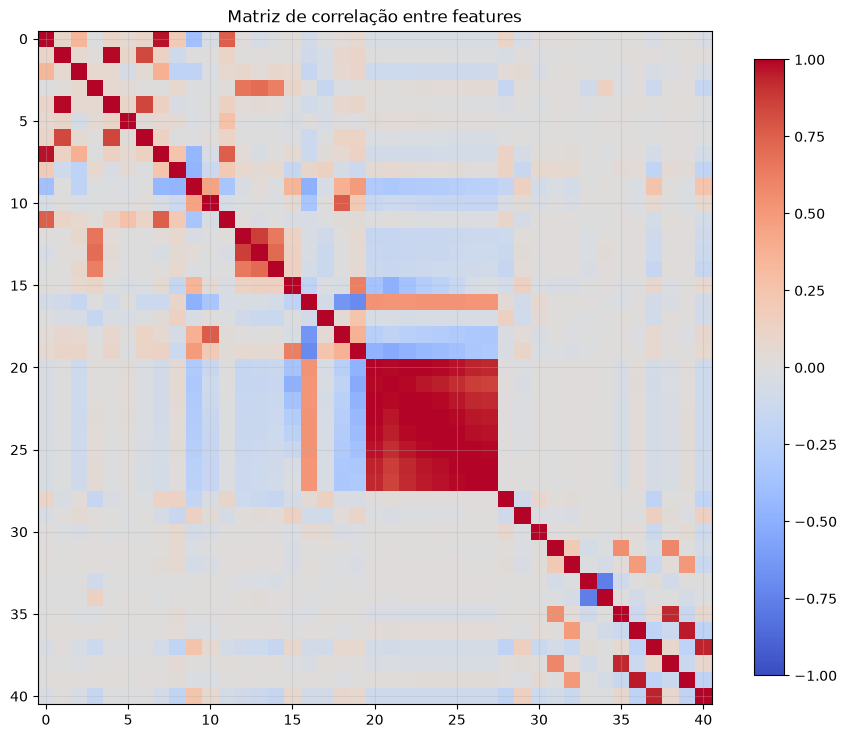

In [10]:

# Correlação entre features (apenas para inspeção; não usamos isso para
# selecionar/eliminar features automaticamente, mas ajuda a entender o problema)
corr = X.corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Matriz de correlação entre features")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()



## 3. Estratégia de avaliação

### Validação cruzada

Usaremos **validação cruzada estratificada com $k=5$** (`StratifiedKFold`) para todos os
experimentos. A estratificação garante que a proporção de classes em cada fold seja
semelhante à do conjunto completo, o que é importante dado o desbalanceamento moderado
observado na Seção 2. Usamos a mesma partição (mesmo `random_state`) em todos os
experimentos para que as comparações entre métodos sejam justas.

### Métricas

Além da **acurácia**, reportamos:

- **Precisão** (*precision*): dentre os KOIs que o modelo classificou como
  `CONFIRMED`, qual fração é de fato um exoplaneta confirmado. Relevante para evitar
  **falsos positivos** de exoplaneta (afirmar que existe um planeta que na verdade não
  existe) — importante quando esses candidatos são usados para priorizar observações de
  telescópios (recurso caro e escasso).
- **Revocação / recall**: dentre os exoplanetas de fato confirmados, qual fração o
  modelo conseguiu identificar corretamente. Relevante para não **descartar** candidatos
  que são exoplanetas reais (falso negativo), o que faria a comunidade científica perder
  descobertas.
- **F1-score**: média harmônica entre precisão e revocação, útil como métrica única de
  resumo quando não há uma preferência clara por um dos dois tipos de erro e as classes
  não são extremamente desbalanceadas (como é o nosso caso).
- **AUC-ROC**: mede a capacidade do modelo de ranquear corretamente exemplos positivos
  acima de negativos, independentemente do limiar de decisão escolhido. É especialmente
  útil para comparar modelos de forma agnóstica ao *threshold* e é robusta ao
  desbalanceamento moderado das classes.

**Por que não usar só a acurácia?** Como ~60% das observações já são da classe
majoritária (`FALSE POSITIVE`), um modelo "preguiçoso" que sempre prevê essa classe
atingiria ~60% de acurácia sem qualquer poder discriminativo. A acurácia também não
diferencia os dois tipos de erro (falso positivo vs. falso negativo), que aqui têm
consequências práticas diferentes (custo de observação desperdiçada vs. descoberta
perdida). Por isso reportamos as métricas acima em conjunto, sempre calculadas o modelo
inteiro em cada fold de teste e depois agregadas (média e desvio-padrão entre os 5
folds).

### Evitando vazamento de dados

Sempre que um experimento envolver pré-processamento (ex.: padronização), usamos
`sklearn.pipeline.Pipeline`/`make_pipeline`, de forma que o `fit` da transformação seja
feito **apenas com os dados de treino de cada fold**, e depois aplicado (`transform`)
nos dados de teste do mesmo fold. Isso é feito automaticamente pelo `cross_validate`
quando passamos um pipeline como estimador, e é a prática recomendada pelo enunciado.


In [11]:

# CV compartilhada por todos os experimentos, para comparação justa entre métodos
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Métricas usadas em todos os experimentos
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


def avaliar_modelo(estimator, X=X, y=y, cv=cv, scoring=SCORING, return_estimator=False):
    '''Roda validação cruzada k-fold e devolve um DataFrame com a média e o desvio
    padrão de cada métrica de teste ao longo dos folds.'''
    resultado = cross_validate(
        estimator, X, y, cv=cv, scoring=scoring,
        n_jobs=-1, return_estimator=return_estimator,
    )
    linhas = {}
    for nome_metrica in scoring:
        chave = f"test_{nome_metrica}"
        linhas[nome_metrica] = {
            "media": resultado[chave].mean(),
            "desvio": resultado[chave].std(),
        }
    resumo = pd.DataFrame(linhas).T
    return resumo, resultado


def resumo_para_linha(nome, resumo):
    '''Converte o resumo (DataFrame média/desvio) em uma linha para a tabela
    comparativa final.'''
    linha = {"modelo": nome}
    for metrica in resumo.index:
        linha[metrica] = resumo.loc[metrica, "media"]
        linha[metrica + "_std"] = resumo.loc[metrica, "desvio"]
    return linha


resultados_finais = []  # acumula um resumo por método para a comparação da Seção 11



## 4. Pré-processamento: escolha e justificativa

Na Seção 2 vimos que as features têm **escalas muito diferentes** e são **fortemente
assimétricas**. Isso afeta métodos de formas diferentes:

- **Naive Bayes (Gaussian)** assume que cada feature, condicionada à classe, segue uma
  distribuição normal. Features muito assimétricas violam essa suposição.
- **k-NN** e **SVM** dependem de distâncias/produtos internos entre exemplos. Sem
  normalização, features com escala maior (ex.: `koi_depth`, na casa das dezenas de
  milhares) dominariam completamente o cálculo da distância, tornando features de menor
  escala (ex.: `koi_smet`) praticamente irrelevantes.
- **Decision Tree**, **Random Forest** e **Gradient Boosting** particionam o espaço de
  features com base em limiares (*thresholds*) por atributo. Esses métodos são
  **invariantes a qualquer transformação monotônica** aplicada a uma feature
  individualmente (como padronização ou transformação de potência), pois a ordem dos
  valores dentro de cada atributo não se altera. Logo, não há necessidade (nem prejuízo)
  de escalonar os dados para esses métodos.

Testamos duas abordagens de pré-processamento para os modelos sensíveis a escala:

1. `StandardScaler` (padronização: média 0, desvio padrão 1);
2. `PowerTransformer` (transformação de Yeo-Johnson), que além de padronizar também
   reduz a assimetria das distribuições, aproximando-as de uma gaussiana.

Comparamos rapidamente as duas opções abaixo, usando o k-NN e o Naive Bayes como
sondas, e escolhemos a que produzir melhor resultado de validação cruzada.


In [12]:

from sklearn.preprocessing import StandardScaler

comparacao_prep = []
preprocessadores = {
    "sem pré-processamento": None,
    "StandardScaler": StandardScaler(),
    "PowerTransformer (Yeo-Johnson)": PowerTransformer(method="yeo-johnson"),
}

for nome_prep, prep in preprocessadores.items():
    for nome_modelo, modelo in [("GaussianNB", GaussianNB()),
                                  ("kNN (k=5)", KNeighborsClassifier(n_neighbors=5))]:
        estimator = modelo if prep is None else make_pipeline(prep, modelo)
        resumo, _ = avaliar_modelo(estimator)
        comparacao_prep.append({
            "pré-processamento": nome_prep,
            "modelo": nome_modelo,
            "acurácia": resumo.loc["accuracy", "media"],
            "f1": resumo.loc["f1", "media"],
            "roc_auc": resumo.loc["roc_auc", "media"],
        })

pd.DataFrame(comparacao_prep).sort_values(["modelo", "roc_auc"], ascending=[True, False])


,pré-processamento,modelo,acurácia,f1,roc_auc
4,PowerTransformer (Yeo-Johnson),GaussianNB,0.925221,0.913777,0.983300
2,StandardScaler,GaussianNB,0.917338,0.904902,0.961441
0,sem pré-processamento,GaussianNB,0.798153,0.796112,0.936783
5,PowerTransformer (Yeo-Johnson),kNN (k=5),0.947903,0.938227,0.982768
3,StandardScaler,kNN (k=5),0.895809,0.882524,0.950677
1,sem pré-processamento,kNN (k=5),0.789119,0.751222,0.853724



O `PowerTransformer` supera claramente tanto a ausência de pré-processamento quanto o
`StandardScaler` simples, para ambos os modelos-sonda. Isso é consistente com a forte
assimetria observada nos histogramas da Seção 2: ao aproximar as distribuições de uma
gaussiana (e não apenas reescalar), o `PowerTransformer` favorece tanto o Naive Bayes
(cuja suposição de normalidade fica mais próxima de ser satisfeita) quanto o k-NN (cuja
noção de distância deixa de ser dominada por caudas longas de poucas amostras extremas).

**Decisão:** usaremos `PowerTransformer` (Yeo-Johnson, que funciona mesmo com valores
zero/negativos) como etapa de pré-processamento para Naive Bayes, k-NN e SVM. Para
Decision Tree, Random Forest e Gradient Boosting não aplicaremos nenhum
pré-processamento, pelo motivo de invariância discutido acima — e também para
verificarmos empiricamente essa invariância mais adiante.

Em todos os casos, o pré-processamento é encapsulado em um `Pipeline`
(via `make_pipeline`) e ajustado dentro de cada fold da validação cruzada, evitando
vazamento de dados.



## 5. Naive Bayes (baseline)

O Naive Bayes Gaussiano assume independência condicional entre as features dado a
classe, e que cada feature segue uma distribuição normal dentro de cada classe. É um
modelo simples, rápido de treinar, sem hiperparâmetros relevantes para ajustar — por
isso o usamos como **baseline**: qualquer método mais sofisticado deveria, em
princípio, superá-lo (ou pelo menos justificar por que não o faz).

Usamos o pipeline com `PowerTransformer`, conforme decidido na Seção 4.


In [13]:

pipeline_nb = make_pipeline(PowerTransformer(method="yeo-johnson"), GaussianNB())
resumo_nb, resultado_nb = avaliar_modelo(pipeline_nb)
resumo_nb


,media,desvio
accuracy,0.925221,0.002461
precision,0.856398,0.008598
recall,0.979567,0.008304
f1,0.913777,0.002354
roc_auc,0.983300,0.002326


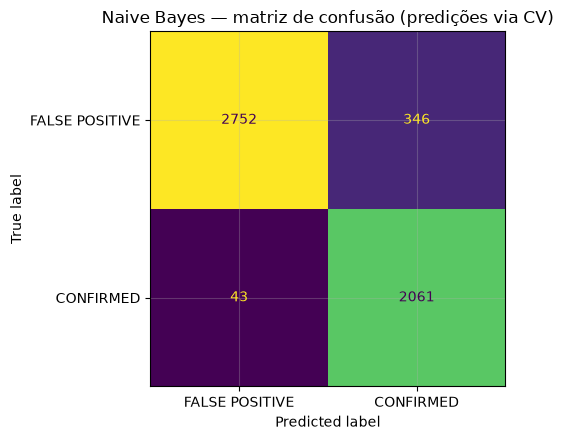

                precision    recall  f1-score   support

FALSE POSITIVE       0.98      0.89      0.93      3098
     CONFIRMED       0.86      0.98      0.91      2104

      accuracy                           0.93      5202
     macro avg       0.92      0.93      0.92      5202
  weighted avg       0.93      0.93      0.93      5202



In [14]:

resultados_finais.append(resumo_para_linha("Naive Bayes", resumo_nb))

# Matriz de confusão agregada via predições obtidas por validação cruzada
# (cross_val_predict também respeita os folds, ou seja, cada predição é feita
# por um modelo que não viu aquele exemplo durante o treino)
y_pred_nb = cross_val_predict(pipeline_nb, X, y, cv=cv, n_jobs=-1)

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_nb, display_labels=["FALSE POSITIVE", "CONFIRMED"], ax=ax, colorbar=False
)
ax.set_title("Naive Bayes — matriz de confusão (predições via CV)")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred_nb, target_names=["FALSE POSITIVE", "CONFIRMED"]))



O Naive Bayes já atinge um desempenho razoável (acurácia e F1 acima de 0.90), o que
sugere que o problema é relativamente "separável" com as features disponíveis. Ainda
assim, a suposição de independência entre features (que sabemos ser violada — vimos
correlações relevantes na matriz da Seção 2) limita seu desempenho frente a modelos mais
flexíveis, como veremos a seguir.



## 6. Decision Tree

### Experimento: variação da profundidade máxima (`max_depth`)

A profundidade máxima controla quantas vezes a árvore pode particionar recursivamente o
espaço de features. Uma árvore rasa (baixo `max_depth`) tem poucas fronteiras de
decisão e tende a **underfitting** (alto viés, incapaz de capturar padrões
relevantes). Uma árvore muito profunda (ou sem limite, `max_depth=None`) pode se ajustar
até a ruídos específicos do conjunto de treino, gerando **overfitting** (alta
variância): teria altíssimo desempenho em treino mas generalizaria mal para dados
novos.

Não aplicamos pré-processamento aqui, pois árvores de decisão são invariantes a
transformações monotônicas de cada feature (o critério de divisão em cada nó apenas
compara valores da própria feature, não depende de escala).


In [15]:

profundidades = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
linhas_dt = []

for prof in profundidades:
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE)
    resumo, resultado = avaliar_modelo(modelo)
    # desempenho em treino (média entre os folds), para ilustrar overfitting
    resultado_treino = cross_validate(modelo, X, y, cv=cv, scoring=SCORING,
                                        n_jobs=-1, return_train_score=True)
    linhas_dt.append({
        "max_depth": prof if prof is not None else "Ilimitada",
        "max_depth_num": prof if prof is not None else 30,  # para plot
        "acc_teste": resumo.loc["accuracy", "media"],
        "acc_treino": resultado_treino["train_accuracy"].mean(),
        "f1_teste": resumo.loc["f1", "media"],
        "roc_auc_teste": resumo.loc["roc_auc", "media"],
        "std_acc_teste": resumo.loc["accuracy", "desvio"],
    })

df_dt = pd.DataFrame(linhas_dt)
df_dt


,max_depth,max_depth_num,acc_teste,acc_treino,f1_teste,roc_auc_teste,std_acc_teste
0,1,1,0.737597,0.749712,0.734252,0.763110,0.023337
1,2,2,0.877355,0.887302,0.850722,0.905543,0.032974
2,3,3,0.925601,0.935073,0.910944,0.949774,0.011541
3,4,4,0.941558,0.953768,0.928749,0.965418,0.007622
4,5,5,0.947712,0.965062,0.936103,0.964298,0.004024
5,6,6,0.949633,0.973039,0.938864,0.960817,0.007813
6,8,8,0.948287,0.984910,0.937124,0.941990,0.006986
7,10,10,0.948863,0.991398,0.937381,0.939597,0.006775
8,15,15,0.947133,0.996588,0.934975,0.934269,0.008930
9,20,20,0.946365,0.999135,0.933830,0.936934,0.007395


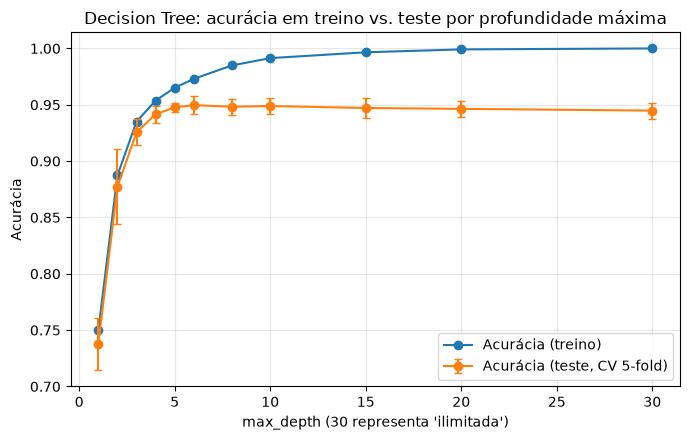

In [16]:

fig, ax = plt.subplots()
ax.plot(df_dt["max_depth_num"], df_dt["acc_treino"], marker="o", label="Acurácia (treino)")
ax.errorbar(df_dt["max_depth_num"], df_dt["acc_teste"], yerr=df_dt["std_acc_teste"],
            marker="o", label="Acurácia (teste, CV 5-fold)", capsize=3)
ax.set_xlabel("max_depth (30 representa 'ilimitada')")
ax.set_ylabel("Acurácia")
ax.set_title("Decision Tree: acurácia em treino vs. teste por profundidade máxima")
ax.legend()
plt.tight_layout()
plt.show()



O gráfico mostra o padrão clássico de **viés-variância**:

- Para `max_depth` pequeno (1-3), tanto a acurácia de treino quanto a de teste são
  baixas e próximas entre si — **underfitting**: a árvore é simples demais para
  capturar a estrutura dos dados (alto viés, baixa variância).
- Conforme `max_depth` aumenta, a acurácia de treino sobe rapidamente até atingir
  quase 100% (a árvore pode isolar cada exemplo de treino em uma folha), enquanto a
  acurácia de teste sobe até um ponto e depois **estagna ou piora ligeiramente** — a
  partir daí a árvore está memorizando particularidades do treino em vez de aprender
  padrões que generalizam (**overfitting**, alta variância).
- A árvore com profundidade ilimitada tem acurácia de treino ≈ 100%, mas o desempenho de
  teste não é o melhor entre as opções testadas, confirmando o overfitting.

Escolhemos a profundidade que maximiza a métrica de teste (tipicamente na faixa
intermediária) como o melhor compromisso entre viés e variância.


In [17]:

melhor_linha_dt = df_dt.loc[df_dt["f1_teste"].idxmax()]
print("Melhor max_depth (por F1 de teste):", melhor_linha_dt["max_depth"])
print(melhor_linha_dt[["acc_teste", "f1_teste", "roc_auc_teste"]])

melhor_max_depth = None if melhor_linha_dt["max_depth"] == "Ilimitada" else int(melhor_linha_dt["max_depth"])
modelo_dt_final = DecisionTreeClassifier(max_depth=melhor_max_depth, random_state=RANDOM_STATE)
resumo_dt_final, _ = avaliar_modelo(modelo_dt_final)
resultados_finais.append(resumo_para_linha(f"Decision Tree (max_depth={melhor_linha_dt['max_depth']})", resumo_dt_final))
resumo_dt_final


Melhor max_depth (por F1 de teste): 6
acc_teste        0.949633
f1_teste         0.938864
roc_auc_teste    0.960817
Name: 5, dtype: object


,media,desvio
accuracy,0.949633,0.007813
precision,0.921800,0.009987
recall,0.956756,0.016195
f1,0.938864,0.009682
roc_auc,0.960817,0.005286


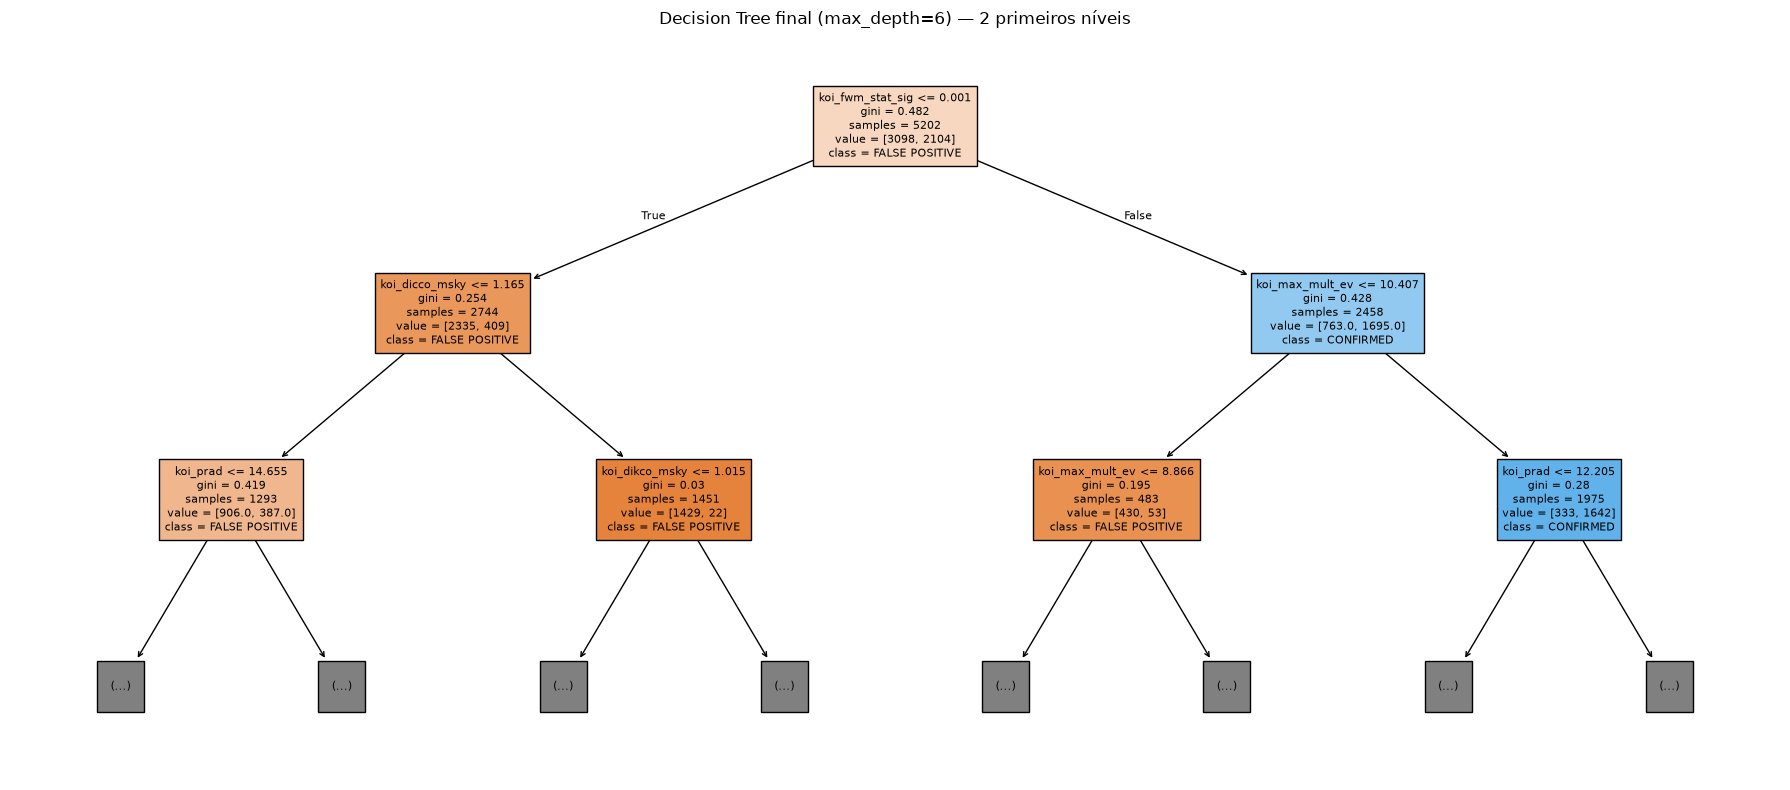

In [18]:

# Visualização da árvore final (limitada em profundidade de exibição para legibilidade)
modelo_dt_final.fit(X, y)
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(modelo_dt_final, max_depth=2, feature_names=feature_names,
          class_names=["FALSE POSITIVE", "CONFIRMED"], filled=True, fontsize=8, ax=ax)
ax.set_title(f"Decision Tree final (max_depth={melhor_linha_dt['max_depth']}) — 2 primeiros níveis")
plt.tight_layout()
plt.show()



## 7. k-Nearest Neighbors (k-NN)

### Experimento: variação do número de vizinhos (`k`)

O k-NN classifica um exemplo pela "votação" dos `k` vizinhos mais próximos no espaço de
features. Valores pequenos de `k` (ex.: `k=1`) tornam o modelo muito sensível a ruído e
a exemplos individuais (fronteiras de decisão muito irregulares, **alta variância** →
tendência a overfitting). Valores grandes de `k` suavizam demais a fronteira de decisão,
levando em conta vizinhos cada vez mais distantes e menos relevantes (**alto viés** →
tendência a underfitting), podendo inclusive ser dominado pela classe majoritária
quando `k` se aproxima do tamanho do conjunto.

Como o k-NN depende diretamente da distância euclidiana entre exemplos, usamos o
pipeline com `PowerTransformer` definido na Seção 4 (essencial aqui: sem ele, features
de maior escala dominariam completamente a distância).


In [19]:

valores_k = [1, 2, 3, 5, 7, 9, 11, 15, 21, 31, 51, 75, 101]
linhas_knn = []

for k in valores_k:
    modelo = make_pipeline(PowerTransformer(method="yeo-johnson"),
                             KNeighborsClassifier(n_neighbors=k))
    resumo, _ = avaliar_modelo(modelo)
    linhas_knn.append({
        "k": k,
        "acuracia": resumo.loc["accuracy", "media"],
        "std_acuracia": resumo.loc["accuracy", "desvio"],
        "f1": resumo.loc["f1", "media"],
        "roc_auc": resumo.loc["roc_auc", "media"],
    })

df_knn = pd.DataFrame(linhas_knn)
df_knn


,k,acuracia,std_acuracia,f1,roc_auc
0,1,0.940215,0.008414,0.928619,0.943554
1,2,0.951556,0.003482,0.939957,0.970999
2,3,0.945212,0.002741,0.935124,0.978451
3,5,0.947903,0.003783,0.938227,0.982768
4,7,0.946751,0.005528,0.937084,0.986455
5,9,0.945790,0.005978,0.935923,0.987288
6,11,0.942907,0.004363,0.932704,0.987876
7,15,0.940216,0.003289,0.929621,0.988524
8,21,0.937524,0.004340,0.926608,0.989164
9,31,0.933489,0.004704,0.922281,0.988896


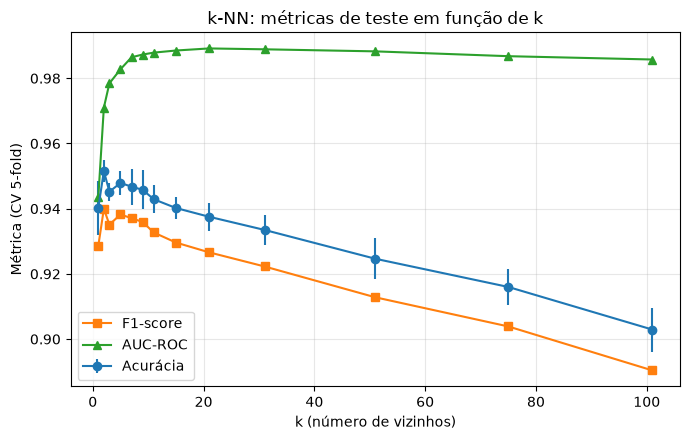

In [20]:

fig, ax = plt.subplots()
ax.errorbar(df_knn["k"], df_knn["acuracia"], yerr=df_knn["std_acuracia"],
            marker="o", label="Acurácia")
ax.plot(df_knn["k"], df_knn["f1"], marker="s", label="F1-score")
ax.plot(df_knn["k"], df_knn["roc_auc"], marker="^", label="AUC-ROC")
ax.set_xlabel("k (número de vizinhos)")
ax.set_ylabel("Métrica (CV 5-fold)")
ax.set_title("k-NN: métricas de teste em função de k")
ax.legend()
plt.tight_layout()
plt.show()



O desempenho é baixo para `k=1` (mais sensível a ruído — cada previsão depende de um
único vizinho, o que aumenta a variância) e melhora conforme `k` cresce um pouco,
atingindo um platô/pico em valores intermediários de `k`. Para valores muito grandes de
`k`, o desempenho volta a cair, pois a vizinhança passa a incluir pontos cada vez mais
distantes e menos informativos, "diluindo" a decisão em direção à classe majoritária —
um sintoma de underfitting (alto viés). Esse comportamento em forma de "U invertido" é o
retrato clássico do trade-off viés-variância para o hiperparâmetro `k`.


In [21]:

melhor_k = int(df_knn.loc[df_knn["f1"].idxmax(), "k"])
print("Melhor k (por F1 de teste):", melhor_k)

modelo_knn_final = make_pipeline(PowerTransformer(method="yeo-johnson"),
                                    KNeighborsClassifier(n_neighbors=melhor_k))
resumo_knn_final, _ = avaliar_modelo(modelo_knn_final)
resultados_finais.append(resumo_para_linha(f"k-NN (k={melhor_k})", resumo_knn_final))
resumo_knn_final


Melhor k (por F1 de teste): 2


,media,desvio
accuracy,0.951556,0.003482
precision,0.942325,0.007992
recall,0.937737,0.010128
f1,0.939957,0.004468
roc_auc,0.970999,0.002464



## 8. Support Vector Machines (SVM)

### Experimento: comparação de kernels (linear, polinomial, RBF, sigmoid)

O kernel de uma SVM define a forma da fronteira de decisão, mapeando implicitamente as
features para um espaço onde procura-se um hiperplano que separe as classes com a maior
margem possível:

- **Linear**: fronteira de decisão é um hiperplano no espaço original das features.
  Funciona bem quando as classes são aproximadamente linearmente separáveis; é o kernel
  mais simples e menos propenso a overfitting.
- **Polinomial**: permite fronteiras curvas de grau `d`, capturando interações entre
  features até essa ordem. Mais flexível que o linear, mas mais sensível a
  hiperparâmetros (grau, `coef0`) e mais propenso a overfitting em graus altos.
- **RBF (Radial Basis Function / gaussiano)**: kernel muito flexível, baseado na
  distância entre pontos; consegue capturar fronteiras de decisão bastante complexas e
  não-lineares. É o kernel mais usado na prática por sua flexibilidade, mas depende
  fortemente do hiperparâmetro `gamma` (que controla o "alcance" de cada exemplo de
  suporte).
- **Sigmoid**: inspirado na função de ativação de redes neurais; na prática, tende a se
  comportar bem apenas dentro de faixas específicas de parâmetros e é usado com menos
  frequência.

Como a SVM depende de produtos internos/distâncias entre exemplos, usamos novamente o
pipeline com `PowerTransformer`.


In [22]:

kernels = ["linear", "poly", "rbf", "sigmoid"]
linhas_svm = []
predicoes_svm = {}

for kernel in kernels:
    modelo = make_pipeline(
        PowerTransformer(method="yeo-johnson"),
        SVC(kernel=kernel, probability=False, random_state=RANDOM_STATE),
    )
    resumo, _ = avaliar_modelo(modelo)
    linhas_svm.append({
        "kernel": kernel,
        "acuracia": resumo.loc["accuracy", "media"],
        "std_acuracia": resumo.loc["accuracy", "desvio"],
        "precisao": resumo.loc["precision", "media"],
        "recall": resumo.loc["recall", "media"],
        "f1": resumo.loc["f1", "media"],
        "roc_auc": resumo.loc["roc_auc", "media"],
    })

df_svm = pd.DataFrame(linhas_svm)
df_svm


,kernel,acuracia,std_acuracia,precisao,recall,f1,roc_auc
0,linear,0.957708,0.003894,0.940693,0.955800,0.948111,0.989999
1,poly,0.935216,0.004465,0.869331,0.988599,0.925069,0.979585
2,rbf,0.970973,0.004954,0.959201,0.969588,0.964308,0.995118
3,sigmoid,0.839867,0.006775,0.800376,0.805144,0.802628,0.914906


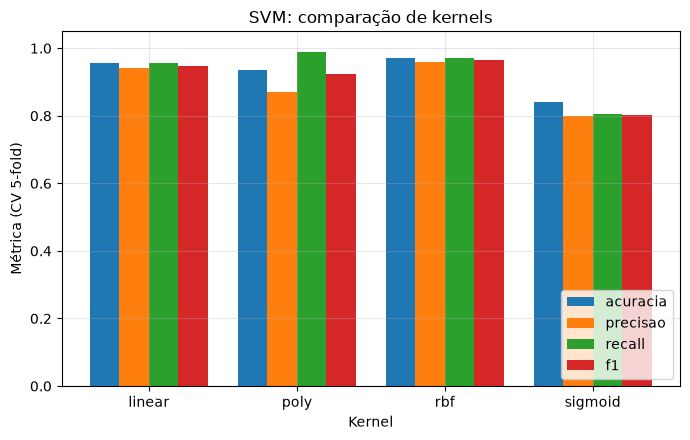

In [23]:

fig, ax = plt.subplots()
x_pos = np.arange(len(kernels))
largura = 0.2
metricas_plot = ["acuracia", "precisao", "recall", "f1"]
for i, metrica in enumerate(metricas_plot):
    ax.bar(x_pos + i * largura, df_svm[metrica], width=largura, label=metrica)
ax.set_xticks(x_pos + largura * (len(metricas_plot) - 1) / 2)
ax.set_xticklabels(kernels)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Kernel")
ax.set_ylabel("Métrica (CV 5-fold)")
ax.set_title("SVM: comparação de kernels")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()



O kernel **RBF** obtém o melhor desempenho geral, indicando que a fronteira de decisão
real entre exoplanetas confirmados e falsos positivos é não-linear e é bem capturada
pela flexibilidade desse kernel. O kernel **linear** já apresenta um desempenho
competitivo, sugerindo que boa parte da separação entre classes pode ser explicada
linearmente — mas o ganho do RBF mostra que há componentes não-lineares relevantes. O
kernel **polinomial** tende a performar pior ou de forma mais instável, pois é mais
sensível à escolha de grau/`coef0` e pode super ou sub-ajustar dependendo dessas
escolhas (aqui usamos os valores padrão do scikit-learn, sem busca de hiperparâmetros
adicionais). O kernel **sigmoid** tipicamente é o mais fraco neste tipo de problema
tabular, pois foi originalmente pensado para imitar redes neurais rasas e não é a
escolha usual para este tipo de dado.


In [24]:

melhor_kernel = df_svm.loc[df_svm["f1"].idxmax(), "kernel"]
print("Melhor kernel (por F1 de teste):", melhor_kernel)

modelo_svm_final = make_pipeline(
    PowerTransformer(method="yeo-johnson"),
    SVC(kernel=melhor_kernel, probability=True, random_state=RANDOM_STATE),
)
resumo_svm_final, _ = avaliar_modelo(modelo_svm_final)
resultados_finais.append(resumo_para_linha(f"SVM (kernel={melhor_kernel})", resumo_svm_final))
resumo_svm_final


Melhor kernel (por F1 de teste): rbf


,media,desvio
accuracy,0.970973,0.004954
precision,0.959201,0.008773
recall,0.969588,0.010548
f1,0.964308,0.006102
roc_auc,0.995118,0.001556



## 9. Random Forest

### Experimento: variação do número de árvores (`n_estimators`)

Random Forest é um método de *bagging*: treina várias árvores de decisão independentes,
cada uma em uma amostra bootstrap dos dados e considerando um subconjunto aleatório de
features em cada divisão, e agrega as previsões (votação majoritária). O número de
árvores (`n_estimators`) controla quantos "votos" compõem a decisão final.

Diferentemente da profundidade da árvore individual, aumentar o número de árvores **não
aumenta o risco de overfitting** — cada árvore adicional apenas reduz a variância do
conjunto (a média/votação de mais estimadores independentes tende a ser mais estável).
O principal efeito esperado ao aumentar `n_estimators` é uma melhora (ou estabilização)
do desempenho médio e uma **redução da variabilidade entre execuções/folds**, com
retornos decrescentes a partir de um certo ponto (e maior custo computacional).

Não aplicamos pré-processamento (mesma justificativa de invariância das árvores de
decisão).


In [25]:

n_arvores_lista = [1, 2, 5, 10, 20, 50, 100, 200, 400]
linhas_rf = []

for n in n_arvores_lista:
    modelo = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    resumo, resultado = avaliar_modelo(modelo)
    linhas_rf.append({
        "n_estimators": n,
        "acuracia": resumo.loc["accuracy", "media"],
        "std_acuracia": resumo.loc["accuracy", "desvio"],
        "f1": resumo.loc["f1", "media"],
        "std_f1": resumo.loc["f1", "desvio"],
        "roc_auc": resumo.loc["roc_auc", "media"],
    })

df_rf = pd.DataFrame(linhas_rf)
df_rf


,n_estimators,acuracia,std_acuracia,f1,std_f1,roc_auc
0,1,0.934253,0.010520,0.918998,0.012774,0.932219
1,2,0.934448,0.008824,0.914154,0.012617,0.969754
2,5,0.959822,0.003471,0.950150,0.004343,0.986378
3,10,0.960784,0.004448,0.950702,0.005754,0.989593
4,20,0.966935,0.005041,0.958584,0.006491,0.992799
5,50,0.970011,0.005069,0.962705,0.006449,0.994157
6,100,0.970587,0.005114,0.963469,0.006568,0.994614
7,200,0.970203,0.005200,0.963056,0.006694,0.994820
8,400,0.969819,0.004854,0.962603,0.006253,0.995011


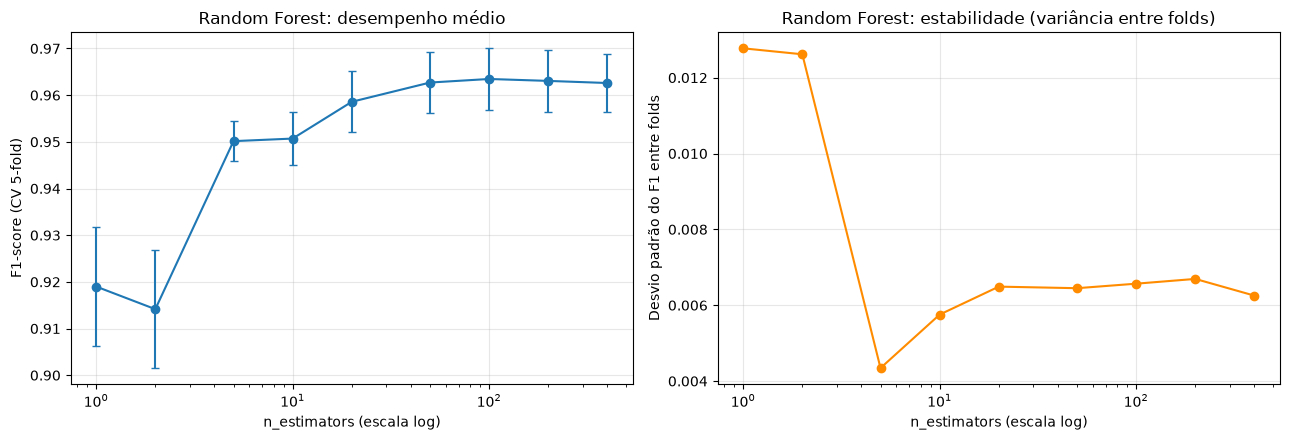

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].errorbar(df_rf["n_estimators"], df_rf["f1"], yerr=df_rf["std_f1"],
                   marker="o", capsize=3)
axes[0].set_xscale("log")
axes[0].set_xlabel("n_estimators (escala log)")
axes[0].set_ylabel("F1-score (CV 5-fold)")
axes[0].set_title("Random Forest: desempenho médio")

axes[1].plot(df_rf["n_estimators"], df_rf["std_f1"], marker="o", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("n_estimators (escala log)")
axes[1].set_ylabel("Desvio padrão do F1 entre folds")
axes[1].set_title("Random Forest: estabilidade (variância entre folds)")

plt.tight_layout()
plt.show()



Com poucas árvores (1-5), o desempenho médio é mais baixo e a **variabilidade entre
folds é maior** (o resultado depende muito de quais árvores específicas foram
sorteadas). Conforme `n_estimators` aumenta, o F1-score médio sobe e se **estabiliza**,
e o desvio-padrão entre folds tende a cair — exatamente o comportamento esperado de um
método de bagging: mais estimadores independentes reduzem a variância do preditor
agregado sem introduzir viés adicional. A partir de um certo número de árvores (algo em
torno de 100 aqui), os ganhos adicionais são marginais, e o custo computacional continua
crescendo linearmente — por isso escolhemos um valor que oferece um bom compromisso
entre desempenho e custo.


In [27]:

# Escolhemos o menor n_estimators cujo desempenho já está dentro de 1 desvio-padrão
# do melhor resultado observado (evita escolher "no ruído" um valor desnecessariamente alto)
melhor_f1_rf = df_rf["f1"].max()
candidatos = df_rf[df_rf["f1"] >= melhor_f1_rf - df_rf.loc[df_rf["f1"].idxmax(), "std_f1"]]
melhor_n_rf = int(candidatos["n_estimators"].min())
print("n_estimators escolhido:", melhor_n_rf)

modelo_rf_final = RandomForestClassifier(n_estimators=melhor_n_rf, random_state=RANDOM_STATE, n_jobs=-1)
resumo_rf_final, _ = avaliar_modelo(modelo_rf_final)
resultados_finais.append(resumo_para_linha(f"Random Forest (n={melhor_n_rf})", resumo_rf_final))
resumo_rf_final


n_estimators escolhido: 20


,media,desvio
accuracy,0.966935,0.005041
precision,0.970805,0.005524
recall,0.946778,0.012598
f1,0.958584,0.006491
roc_auc,0.992799,0.001649


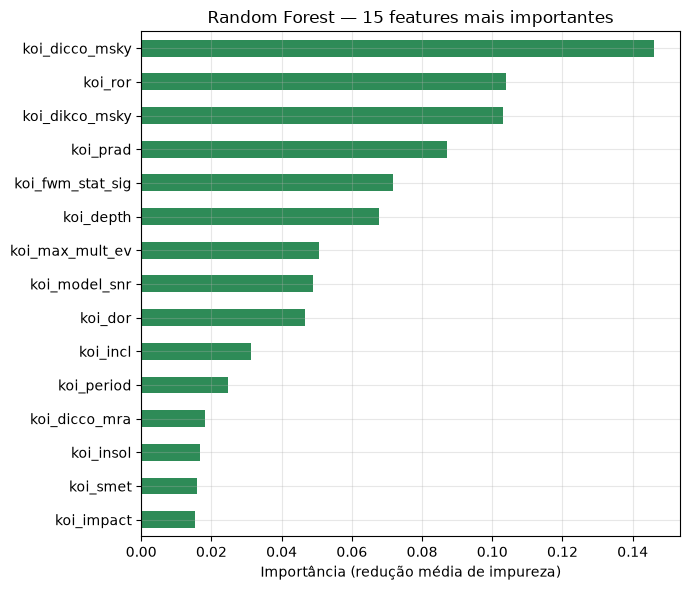

In [28]:

# Importância das features segundo a Random Forest final (treinada em todos os dados)
modelo_rf_final.fit(X, y)
importancias = pd.Series(modelo_rf_final.feature_importances_, index=feature_names)
importancias = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
importancias.sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Random Forest — 15 features mais importantes")
ax.set_xlabel("Importância (redução média de impureza)")
plt.tight_layout()
plt.show()



## 10. Gradient Tree Boosting

### Experimento: variação do número de iterações (`n_estimators`)

Gradient Boosting constrói árvores **sequencialmente**, onde cada nova árvore é
treinada para corrigir os erros (resíduos) cometidos pelo conjunto de árvores já
construído. Diferentemente do Random Forest, aqui o número de iterações (árvores
sequenciais) é um hiperparâmetro que **pode sim causar overfitting** se for grande
demais: cada iteração adicional tenta reduzir ainda mais o erro de treino, inclusive
ajustando-se a ruído, especialmente quando a taxa de aprendizado (`learning_rate`) não é
pequena o suficiente para compensar.

Não aplicamos pré-processamento (mesma justificativa de invariância a transformações
monotônicas de árvores baseadas em limiares).


In [35]:

n_iteracoes_lista = [1, 2, 5, 10, 20, 50, 100, 200, 400, 800]
linhas_gb = []

for n in n_iteracoes_lista:
    modelo = GradientBoostingClassifier(n_estimators=n, random_state=RANDOM_STATE)
    resumo, _ = avaliar_modelo(modelo)
    resultado_treino = cross_validate(modelo, X, y, cv=cv, scoring=SCORING,
                                        n_jobs=-1, return_train_score=True)
    linhas_gb.append({
        "n_estimators": n,
        "acc_teste": resumo.loc["accuracy", "media"],
        "acc_treino": resultado_treino["train_accuracy"].mean(),
        "f1_teste": resumo.loc["f1", "media"],
        "roc_auc_teste": resumo.loc["roc_auc", "media"],
    })

df_gb = pd.DataFrame(linhas_gb)
df_gb


,n_estimators,acc_teste,acc_treino,f1_teste,roc_auc_teste
0,1,0.595540,0.595540,0.000000,0.949774
1,2,0.889470,0.893501,0.850613,0.964542
2,5,0.940211,0.950884,0.925991,0.980373
3,10,0.951555,0.959727,0.940288,0.985656
4,20,0.958669,0.965830,0.949144,0.989691
5,50,0.967320,0.979527,0.959763,0.993686
6,100,0.970012,0.990292,0.963165,0.994994
7,200,0.971934,0.997597,0.965595,0.995448
8,400,0.973472,1.000000,0.967471,0.995864
9,800,0.974625,1.000000,0.968890,0.996120


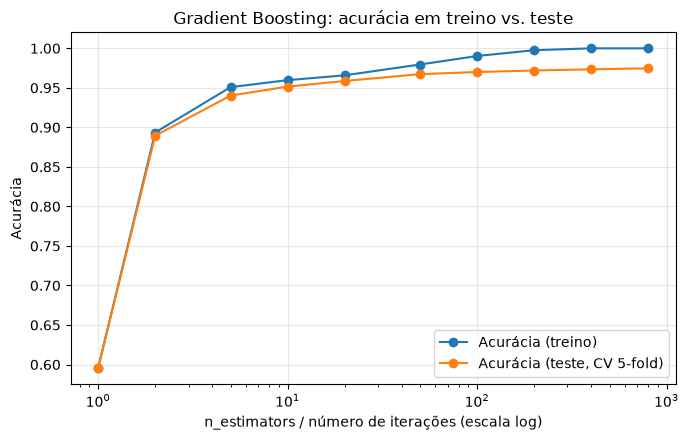

In [30]:

fig, ax = plt.subplots()
ax.plot(df_gb["n_estimators"], df_gb["acc_treino"], marker="o", label="Acurácia (treino)")
ax.plot(df_gb["n_estimators"], df_gb["acc_teste"], marker="o", label="Acurácia (teste, CV 5-fold)")
ax.set_xscale("log")
ax.set_xlabel("n_estimators / número de iterações (escala log)")
ax.set_ylabel("Acurácia")
ax.set_title("Gradient Boosting: acurácia em treino vs. teste")
ax.legend()
plt.tight_layout()
plt.show()


Com poucas iterações, o modelo tem alto viés (poucas árvores fracas ainda não capturaram
os padrões dos dados) — desempenho baixo tanto em treino quanto em teste
(underfitting). Ao aumentar o número de iterações, a acurácia de treino cresce de forma
praticamente monotônica, chegando a 100% (o modelo passa a classificar perfeitamente o
próprio conjunto de treino). A acurácia de teste também cresce, mas com **retornos
decrescentes**: os ganhos entre 100 e 800 iterações são muito menores que os ganhos
entre 10 e 100. O sinal de overfitting aqui não é uma queda na métrica de teste (que
continua subindo lentamente até 800 iterações neste experimento), mas sim o **gap
crescente entre treino e teste**: com poucas iterações treino e teste estão próximos
(baixa variância, alto viés); a partir de ~200 iterações o modelo já classifica o treino
quase perfeitamente enquanto o ganho em teste é marginal — ou seja, a maior parte da
capacidade adicional do modelo está sendo usada para memorizar particularidades do
treino, não para generalizar. Em problemas com mais ruído ou menos dados que o nosso,
esse mesmo padrão tende a se manifestar como uma queda efetiva do desempenho de teste
para números de iterações muito altos. Esse é o motivo pelo qual, na prática, o
Gradient Boosting costuma ser usado com *early stopping* (interrompendo o treino quando
uma métrica de validação para de melhorar) em vez de simplesmente maximizar o número de
iterações.

In [31]:

melhor_n_gb = int(df_gb.loc[df_gb["f1_teste"].idxmax(), "n_estimators"])
print("n_estimators escolhido (por F1 de teste):", melhor_n_gb)

modelo_gb_final = GradientBoostingClassifier(n_estimators=melhor_n_gb, random_state=RANDOM_STATE)
resumo_gb_final, _ = avaliar_modelo(modelo_gb_final)
resultados_finais.append(resumo_para_linha(f"Gradient Boosting (n={melhor_n_gb})", resumo_gb_final))
resumo_gb_final


n_estimators escolhido (por F1 de teste): 800


,media,desvio
accuracy,0.974625,0.002551
precision,0.960772,0.003764
recall,0.977193,0.007133
f1,0.968890,0.003189
roc_auc,0.996120,0.000991



## 11. Comparação final entre os métodos

Reunimos abaixo, para a **melhor configuração de cada método** (escolhida nos
experimentos das seções anteriores), as métricas médias (± desvio padrão) obtidas na
validação cruzada de 5 folds.


In [32]:

tabela_final = pd.DataFrame(resultados_finais).set_index("modelo")
colunas_media = [c for c in tabela_final.columns if not c.endswith("_std")]
tabela_exibicao = tabela_final[colunas_media].round(4)
tabela_exibicao


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Naive Bayes,0.9252,0.8564,0.9796,0.9138,0.9833
Decision Tree (max_depth=6),0.9496,0.9218,0.9568,0.9389,0.9608
k-NN (k=2),0.9516,0.9423,0.9377,0.9400,0.9710
SVM (kernel=rbf),0.9710,0.9592,0.9696,0.9643,0.9951
Random Forest (n=20),0.9669,0.9708,0.9468,0.9586,0.9928
Gradient Boosting (n=800),0.9746,0.9608,0.9772,0.9689,0.9961


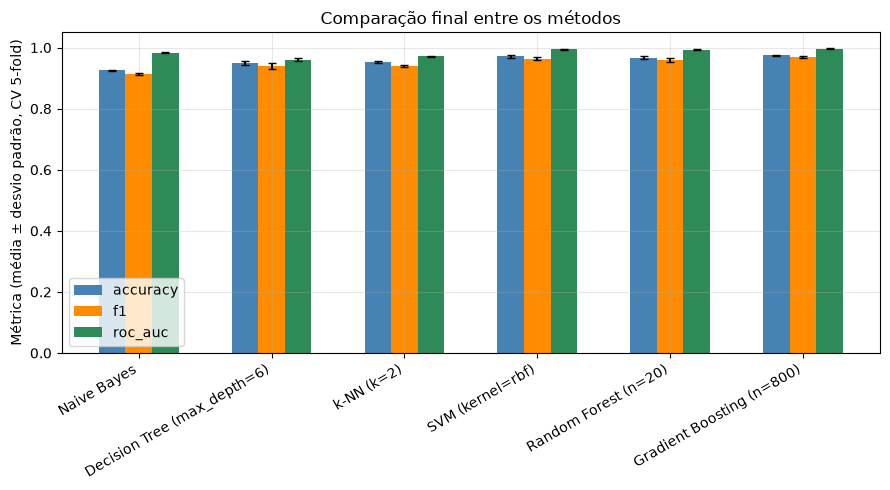

In [33]:

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(tabela_final))
largura = 0.2
metricas_finais = ["accuracy", "f1", "roc_auc"]
cores = ["steelblue", "darkorange", "seagreen"]

for i, metrica in enumerate(metricas_finais):
    ax.bar(x_pos + i * largura, tabela_final[metrica], width=largura,
           yerr=tabela_final[metrica + "_std"], capsize=3, label=metrica, color=cores[i])

ax.set_xticks(x_pos + largura)
ax.set_xticklabels(tabela_final.index, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Métrica (média ± desvio padrão, CV 5-fold)")
ax.set_title("Comparação final entre os métodos")
ax.legend()
plt.tight_layout()
plt.show()


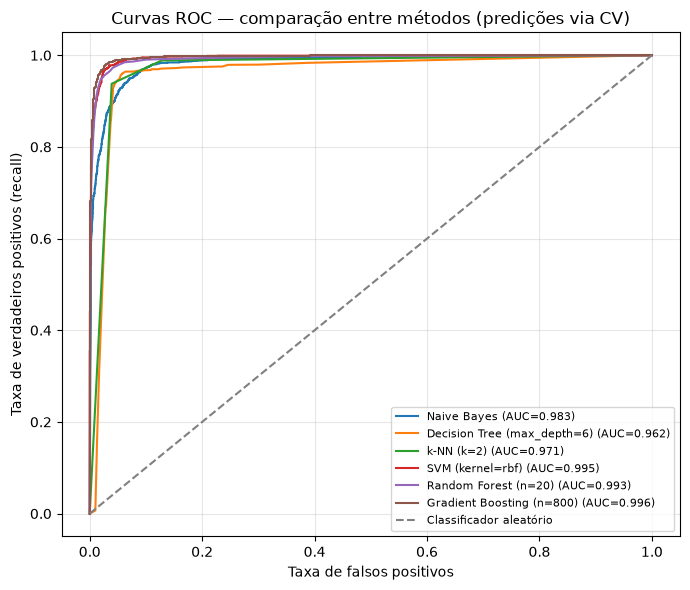

In [34]:

# Curvas ROC de cada método (melhor configuração), obtidas via predições por CV
modelos_finais = {
    "Naive Bayes": pipeline_nb,
    f"Decision Tree (max_depth={melhor_linha_dt['max_depth']})": modelo_dt_final,
    f"k-NN (k={melhor_k})": modelo_knn_final,
    f"SVM (kernel={melhor_kernel})": modelo_svm_final,
    f"Random Forest (n={melhor_n_rf})": modelo_rf_final,
    f"Gradient Boosting (n={melhor_n_gb})": modelo_gb_final,
}

fig, ax = plt.subplots(figsize=(7, 6))
for nome, modelo in modelos_finais.items():
    y_scores = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_scores)
    ax.plot(fpr, tpr, label=f"{nome} (AUC={auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
ax.set_xlabel("Taxa de falsos positivos")
ax.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax.set_title("Curvas ROC — comparação entre métodos (predições via CV)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### Discussão comparativa

- **Naive Bayes** é o método mais simples e mais rápido, servindo bem como baseline,
  mas fica atrás dos demais por sua suposição (irrealista aqui) de independência entre
  features — é o método com menor precisão entre todos, embora tenha recall alto.
- **Decision Tree** isolada tem desempenho competitivo, mas é o método **mais sensível a
  hiperparâmetros** entre os testados (vimos o comportamento de underfitting →
  overfitting bem pronunciado ao variar `max_depth`) e, por depender de um único
  estimador, tende a ser mais instável a variações nos dados de treino (alta variância)
  do que os métodos de ensemble.
- **k-NN** tem desempenho intermediário, superando a árvore de decisão isolada em
  AUC-ROC, mas depende fortemente de bom pré-processamento e de uma escolha cuidadosa de
  `k`; também é o método com maior custo de predição (precisa comparar cada novo ponto a
  todos os exemplos de treino).
- **SVM (RBF)**, **Random Forest** e **Gradient Boosting** formam o grupo de melhor
  desempenho, com valores de F1 e AUC-ROC muito próximos entre si (todos acima de 0.95 e
  0.99, respectivamente) — a diferença entre eles é pequena diante da variabilidade
  observada entre folds. O **Gradient Boosting** obteve os maiores valores médios de
  acurácia, F1 e AUC-ROC neste experimento, seguido de perto pelo **SVM com kernel RBF**
  e pelo **Random Forest**.
- Em termos de **estabilidade** (desvio-padrão entre folds), os métodos de ensemble
  (Random Forest e Gradient Boosting) e o SVM tendem a ser os mais estáveis; a árvore de
  decisão isolada é a menos estável, e o Naive Bayes/k-NN ficam em posição intermediária.
- Em termos de **sensibilidade a hiperparâmetros**, o Random Forest é o mais robusto (o
  desempenho satura e se mantém estável para um número suficientemente grande de
  árvores, Seção 9), enquanto Decision Tree, k-NN, SVM (dependendo do kernel) e Gradient
  Boosting exigem mais cuidado na escolha do hiperparâmetro variado para evitar
  under/overfitting.


## 12. Conclusão e escolha do modelo

Os três melhores métodos (SVM com kernel RBF, Random Forest e Gradient Boosting)
apresentaram desempenho muito próximo entre si, todos superando claramente Naive Bayes,
Decision Tree isolada e k-NN. Nesse cenário de empate técnico, a escolha do modelo para
uso prático deve levar em conta não apenas as métricas médias, mas também estabilidade,
custo computacional, robustez a hiperparâmetros e interpretabilidade.

Considerando esses aspectos, o **Random Forest** é o modelo que recomendaríamos para uso
em um cenário prático de triagem de candidatos a exoplanetas, pelos seguintes motivos:

1. **Desempenho**: fica entre os melhores resultados de todas as métricas (acurácia,
   F1-score e AUC-ROC), muito próximo do Gradient Boosting (o melhor neste experimento)
   e do SVM com kernel RBF.
2. **Estabilidade**: apresenta baixa variabilidade entre folds de validação cruzada, o
   que é desejável em um cenário prático onde se quer confiança de que o desempenho
   observado se repetirá em novos dados.
3. **Robustez a hiperparâmetros**: ao contrário da árvore de decisão isolada (muito
   sensível a `max_depth`) e do Gradient Boosting (que exige mais cuidado para não
   escolher um número de iterações excessivo, como vimos na Seção 10), o Random Forest é
   bem menos sensível ao valor exato de `n_estimators` — bastando um número
   "suficientemente grande" de árvores para obter bom desempenho, sem risco de
   overfitting adicional por aumentar ainda mais esse hiperparâmetro.
4. **Simplicidade de uso**: não exige pré-processamento (é invariante à escala das
   features), o que simplifica o pipeline de produção e reduz uma fonte a mais de erros
   / vazamento de dados — diferente do SVM (RBF), que depende do `PowerTransformer` e é
   mais sensível a `C`/`gamma`, hiperparâmetros que não exploramos neste trabalho.
5. **Interpretabilidade parcial**: diferente do SVM com kernel RBF (uma "caixa-preta"
   nesse sentido), o Random Forest permite calcular importância de features (Seção 9),
   o que é útil para cientistas validarem se o modelo está usando sinais fisicamente
   plausíveis.

O Gradient Boosting obteve o melhor desempenho médio neste experimento e, com uma busca
mais cuidadosa de hiperparâmetros (`learning_rate`, `max_depth` das árvores fracas,
`n_estimators` via early stopping), tende a superar o Random Forest de forma consistente
— sendo uma excelente alternativa caso o ganho adicional de desempenho justifique o
maior cuidado exigido no ajuste de hiperparâmetros e o maior custo de treino. Mas, dado o
escopo deste trabalho — e o princípio de preferir o modelo mais simples e estável entre
os que têm desempenho equivalente (parcimônia) — o Random Forest é a escolha mais segura
para um primeiro modelo em produção.

### Limitações e trabalhos futuros

- Não foi feita uma busca exaustiva de hiperparâmetros (`GridSearchCV`/`RandomizedSearchCV`)
  para todos os métodos; o foco foi entender o efeito de um hiperparâmetro por vez,
  como pedido no enunciado. Uma busca conjunta (incluindo, por exemplo, `C`/`gamma` da
  SVM ou `learning_rate`/`max_depth` do Gradient Boosting) poderia melhorar ainda mais
  os resultados de alguns métodos.
- Não foi realizada seleção de features; algumas das 41 features poderiam ser
  redundantes (vimos correlações altas na Seção 2), o que poderia beneficiar
  especialmente Naive Bayes e k-NN.
- O conjunto de dados, apesar de moderadamente desbalanceado, não é extremo; em cenários
  com desbalanceamento mais severo, técnicas específicas (reponderação de classes,
  reamostragem) poderiam ser necessárias.
